In [2]:
from brian2 import *
import matplotlib.pyplot as plt
import numpy as np

Thalamic→Cortical synapses: 4493
Avg thalamic inputs per cortical neuron: 89.9
Cortical dv/dt at rest with I=50pA: -15.50 mV/ms


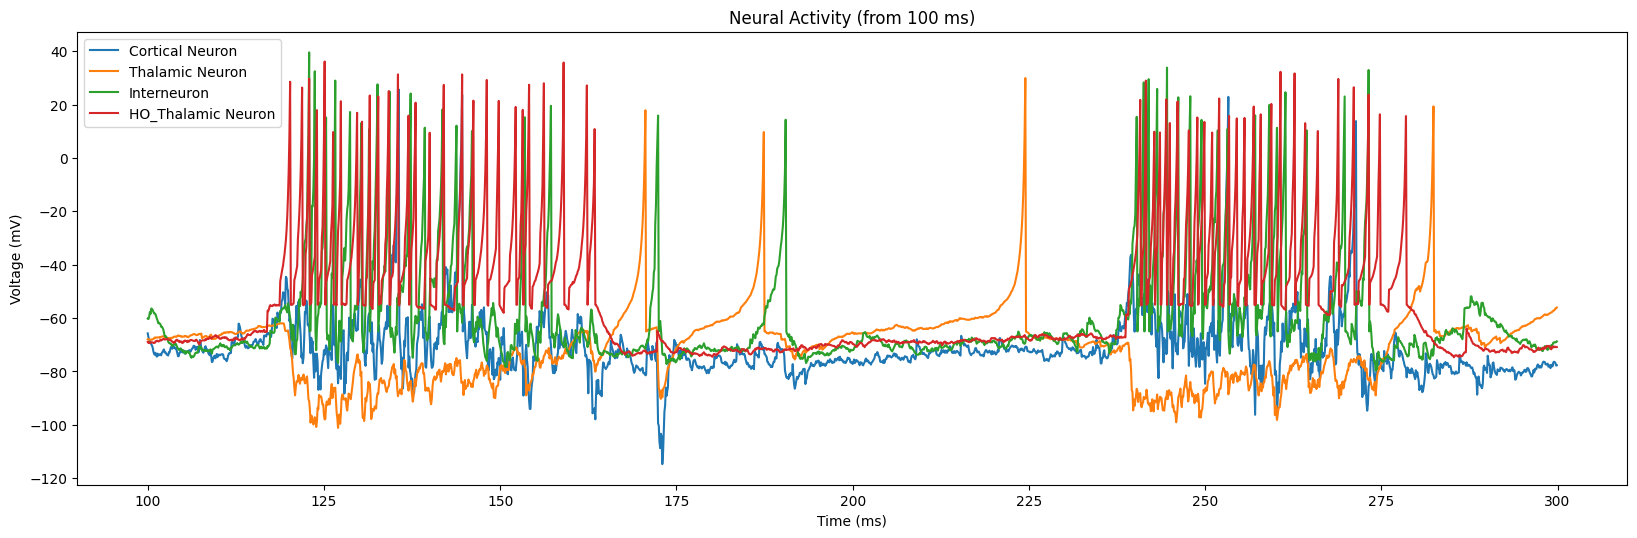

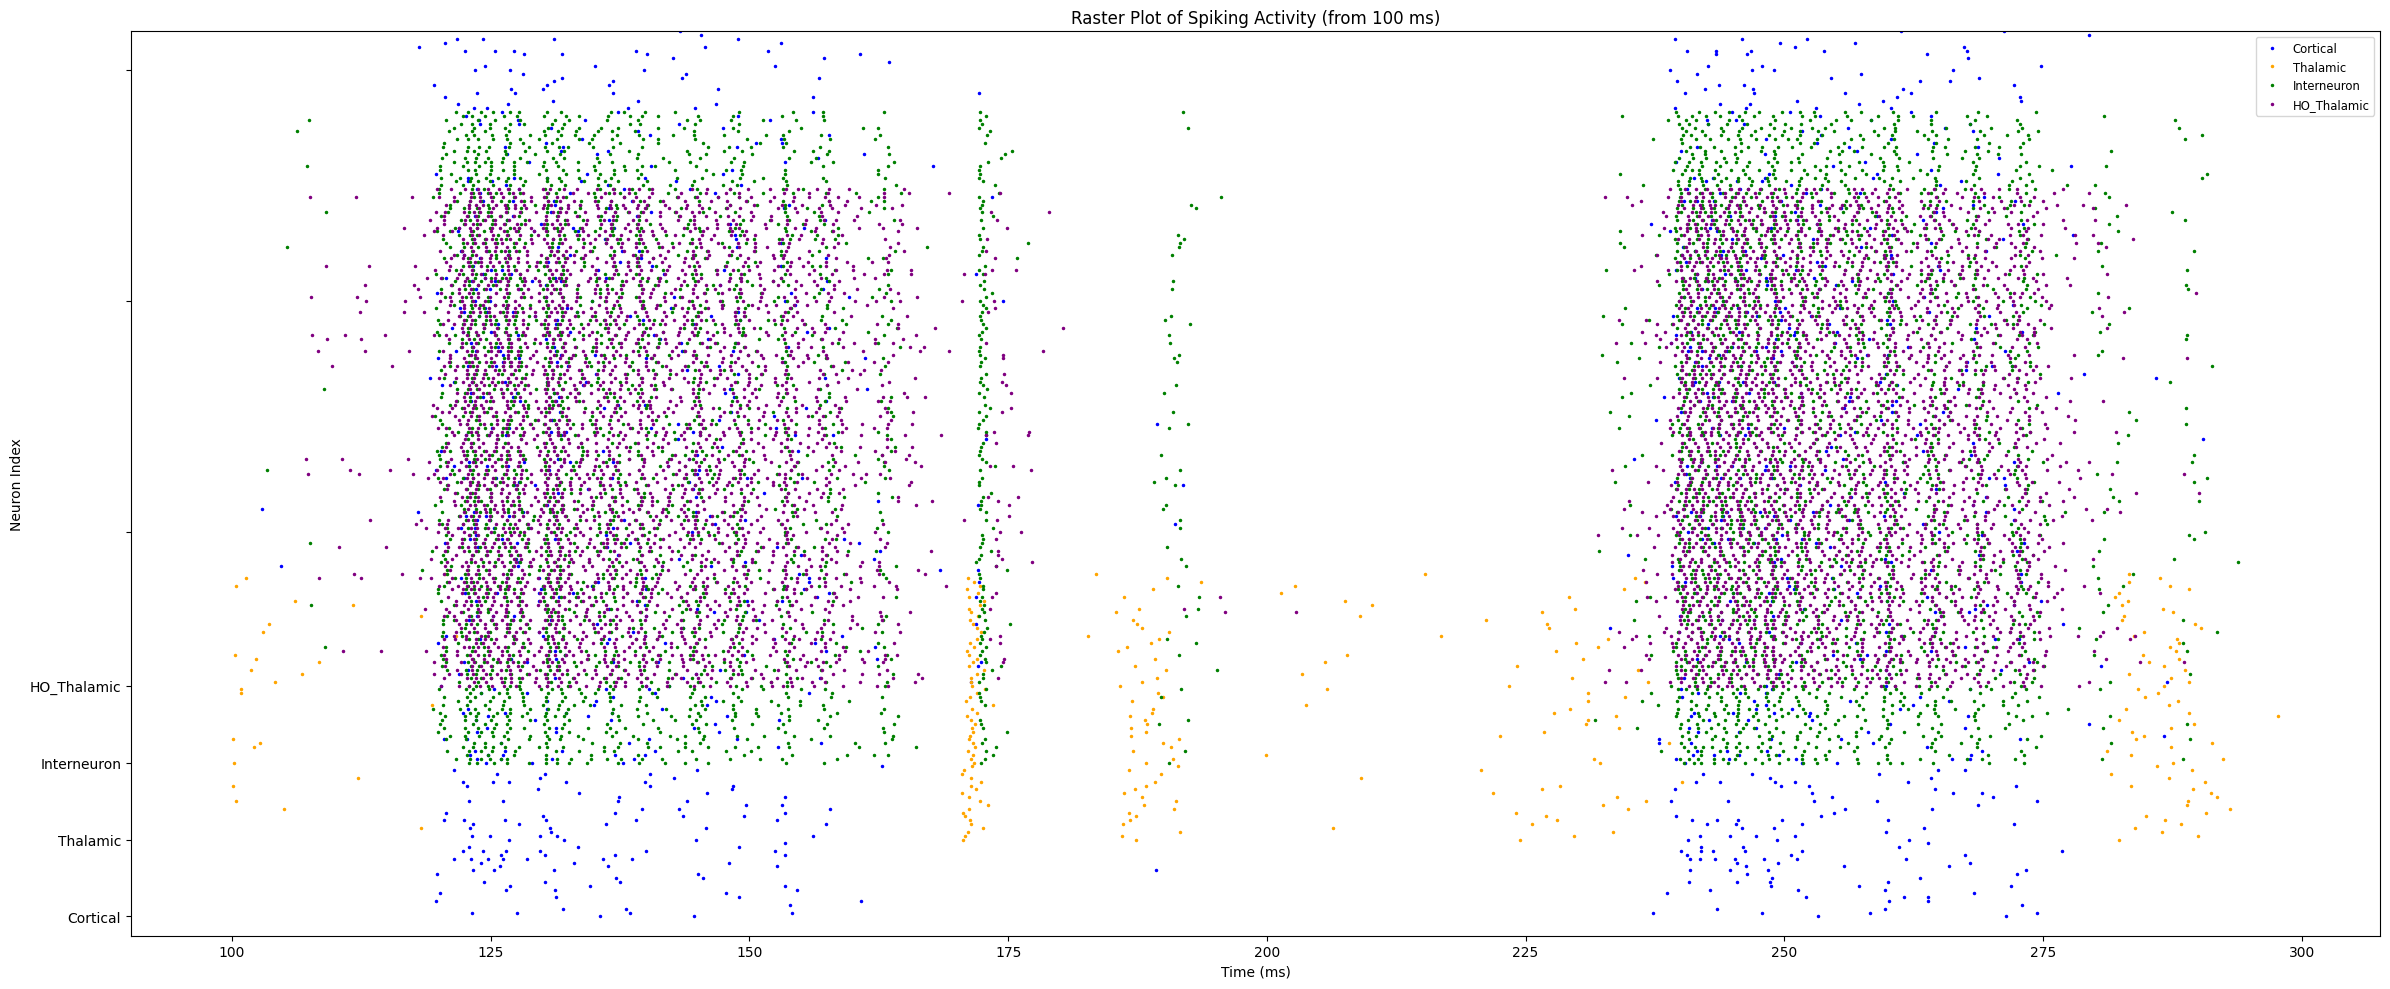

In [26]:
start_scope()

# Parameters

eqs = '''dv/dt = 0.04/mV/ms * v**2 + 5/ms * v + 140*mV/ms - u/ms + I/(100*pF) + sigma*xi*(mV/ms**0.5) : volt
         du/dt = a*(b*v - u)/ms : volt
         I : amp
         sigma : 1
         a : 1
         b : 1
         c : volt
         d : volt
         '''
# Create a cortical neuron group
Cortical = NeuronGroup(650, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='euler') 

Cortical.a = 0.02
Cortical.b = 0.2
Cortical.c = -65*mV
Cortical.d = 8*mV
Cortical.I = '0*pA' # Random background input to cortex 

Cortical.v = Cortical.c
Cortical.u = Cortical.b * -65*mV

# Create a low order thalamic neuron group (e.g., ventral posterior nucleus)
Thalamic = NeuronGroup(70, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='euler')


Thalamic.a = 0.02
Thalamic.b = 0.25
Thalamic.c = -65*mV
Thalamic.d = 2*mV
Thalamic.I = '200*pA' # Only low order thalamic neurons are driven by sensory input

Thalamic.v = Thalamic.c
Thalamic.u = Thalamic.b * -65*mV

# Create a fast-spiking interneuron group
Interneuron = NeuronGroup(170, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='euler')

Interneuron.a = 0.1
Interneuron.b = 0.2
Interneuron.c = -65*mV
Interneuron.d = 0.05*mV
Interneuron.I = '0*pA' # Interneurons are driven by cortex

Interneuron.v = Interneuron.c 
Interneuron.u = Interneuron.b * -65*mV

# Create a high order thalamic neuron group 
HO_Thalamic = NeuronGroup(130, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='euler')
HO_Thalamic.a = 0.02
HO_Thalamic.b = 0.25
HO_Thalamic.c = -55*mV
HO_Thalamic.d = 0.05*mV
HO_Thalamic.I = '0*pA' # High-order thalamic neurons are driven by cortex 

HO_Thalamic.v = HO_Thalamic.c
HO_Thalamic.u = HO_Thalamic.b * -65*mV

# Random noise 

Cortical.sigma = 2.0    # tune this — higher = more irregular firing
Interneuron.sigma = 1.5
HO_Thalamic.sigma = 1.0
Thalamic.sigma = 0.5  

# Create synapses

Cortical_to_Cortical = Synapses(Cortical, Cortical, 'w : volt', on_pre='v += w')
Cortical_to_Cortical.connect(condition= 'i!=j', p=0.15)
Cortical_to_Cortical.w = '0.5*mV + 0.5*mV*rand()'

Cortical_to_Thalamic = Synapses(Cortical, Thalamic, 'w : volt', on_pre='v += w')
Cortical_to_Thalamic.connect( p=0.05)
Cortical_to_Thalamic.w = '1*mV + 0.3*mV*rand()'

Cortical_to_HO_Thalamic = Synapses(Cortical, HO_Thalamic, 'w : volt', on_pre='v += w')
Cortical_to_HO_Thalamic.connect(p=0.05)
Cortical_to_HO_Thalamic.w = '8*mV + 2*mV*rand()'

Cortical_to_Interneuron = Synapses(Cortical, Interneuron, 'w : volt', on_pre='v += w')
Cortical_to_Interneuron.connect(p=0.2)
Cortical_to_Interneuron.w = '5*mV + 0.5*mV*rand()'

Thalamic_to_Cortical = Synapses(Thalamic, Cortical, 'w : volt', on_pre='v += w')
Thalamic_to_Cortical.connect(p=0.1)
Thalamic_to_Cortical.w = '6*mV + 0.5*mV*rand()' 

Thalamic_to_Interneuron = Synapses(Thalamic, Interneuron, 'w : volt', on_pre='v += w')
Thalamic_to_Interneuron.connect(p=0.2)
Thalamic_to_Interneuron.w = '1.5*mV + 1*mV*rand()'

Interneuron_to_Cortical = Synapses(Interneuron, Cortical, 'w : volt', on_pre='v += w')
Interneuron_to_Cortical.connect(p=0.4) 
Interneuron_to_Cortical.w = '-1*mV + (-2*mV*rand())'

Interneuron_to_Interneuron = Synapses(Interneuron, Interneuron, 'w : volt', on_pre='v += w')
Interneuron_to_Interneuron.connect(condition = 'i!=j', p=0.4)
Interneuron_to_Interneuron.w = '-0.5*mV + (-1*mV*rand())'

Interneuron_to_Thalamic = Synapses(Interneuron, Thalamic, 'w : volt', on_pre='v += w')
Interneuron_to_Thalamic.connect(p=0.2)
Interneuron_to_Thalamic.w = '-1*mV + (-1*mV*rand())'

HO_Thalamic_to_Cortical = Synapses(HO_Thalamic, Cortical, 'w : volt', on_pre='v += w')
HO_Thalamic_to_Cortical.connect(p=0.2)
HO_Thalamic_to_Cortical.w = '3*mV + 1*mV*rand()'



# Record the results
MC = StateMonitor(Cortical, 'v', record=True)
MT = StateMonitor(Thalamic, 'v', record=True)
MI = StateMonitor(Interneuron, 'v', record=True)
MR = StateMonitor(HO_Thalamic, 'v', record=True)

Spikemon_Cortical = SpikeMonitor(Cortical)
Spikemon_Thalamic = SpikeMonitor(Thalamic)
Spikemon_Interneuron = SpikeMonitor(Interneuron)
Spikemon_HO_Thalamic = SpikeMonitor(HO_Thalamic)

print(f"Thalamic→Cortical synapses: {len(Thalamic_to_Cortical)}")
print(f"Avg thalamic inputs per cortical neuron: {len(Thalamic_to_Cortical)/50:.1f}")
print(f"Cortical dv/dt at rest with I=50pA: {(0.04*(-65)**2 + 5*(-65) + 140 + 50e-12/1e-10):.2f} mV/ms")

run(300*ms)

# Trim the first 100 ms from plots
trim_ms = 100
trim_mask = (MC.t/ms >= trim_ms)
trim_idx = np.nonzero(trim_mask)[0]

# Plot the results
plt.figure(figsize=(20, 20))
plt.subplot(3, 1, 1)
plt.plot((MC.t/ms)[trim_idx], (MC.v[0]/mV)[trim_idx], label='Cortical Neuron')
plt.plot((MT.t/ms)[trim_idx], (MT.v[0]/mV)[trim_idx], label='Thalamic Neuron')
plt.plot((MI.t/ms)[trim_idx], (MI.v[0]/mV)[trim_idx], label='Interneuron')
plt.plot((MR.t/ms)[trim_idx], (MR.v[0]/mV)[trim_idx], label='HO_Thalamic Neuron')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.title('Neural Activity (from 100 ms)')
plt.show()

# Plot the raster plot
plt.figure(figsize=(24, 10))
plt.plot((Spikemon_Cortical.t/ms)[Spikemon_Cortical.t/ms >= trim_ms], Spikemon_Cortical.i[Spikemon_Cortical.t/ms >= trim_ms], marker='.', linestyle='None', color='blue', markersize=3, label='Cortical')
plt.plot((Spikemon_Thalamic.t/ms)[Spikemon_Thalamic.t/ms >= trim_ms], Spikemon_Thalamic.i[Spikemon_Thalamic.t/ms >= trim_ms] + 20, marker='.', linestyle='None', color='orange', markersize=3, label='Thalamic')
plt.plot((Spikemon_Interneuron.t/ms)[Spikemon_Interneuron.t/ms >= trim_ms], Spikemon_Interneuron.i[Spikemon_Interneuron.t/ms >= trim_ms] + 40, marker='.', linestyle='None', color='green', markersize=3, label='Interneuron')
plt.plot((Spikemon_HO_Thalamic.t/ms)[Spikemon_HO_Thalamic.t/ms >= trim_ms], Spikemon_HO_Thalamic.i[Spikemon_HO_Thalamic.t/ms >= trim_ms] + 60, marker='.', linestyle='None', color='purple', markersize=3, label='HO_Thalamic')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index')
plt.ylim(-5, 230)
plt.yticks([0, 20, 40, 60, 100, 160, 220], ['Cortical', 'Thalamic', 'Interneuron', 'HO_Thalamic', '', '', ''])
plt.legend(loc='upper right', fontsize='small')
plt.title('Raster Plot of Spiking Activity (from 100 ms)')
plt.tight_layout()
plt.show()



Thalamic→Cortical synapses: 150
Avg thalamic inputs per cortical neuron: 3.0
Cortical dv/dt at rest with I=50pA: -15.50 mV/ms


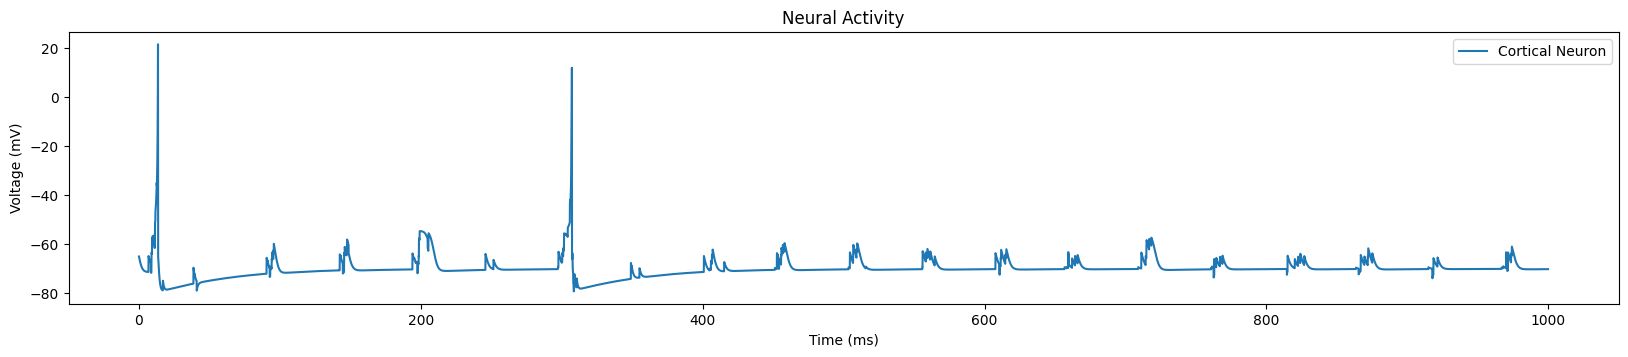

WARNING    C:\Users\goshk\AppData\Local\Temp\ipykernel_21884\116287371.py:138: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  plot(Spikemon_Cortical.t/ms, Spikemon_Cortical.i, '.k', color='blue', markersize=2)
 [py.warnings]
WARNING    C:\Users\goshk\AppData\Local\Temp\ipykernel_21884\116287371.py:139: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  plot(Spikemon_Thalamic.t/ms, Spikemon_Thalamic.i + 10, '.k', color='orange', markersize=2)
 [py.warnings]
WARNING    C:\Users\goshk\AppData\Local\Temp\ipykernel_21884\116287371.py:140: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".r" (-> color='r'). The keyword argument will take precedence.
  plot(Spikemon_Interneuron.t/ms, Spikemon_Interneuron.i + 20, '.r', color='green',

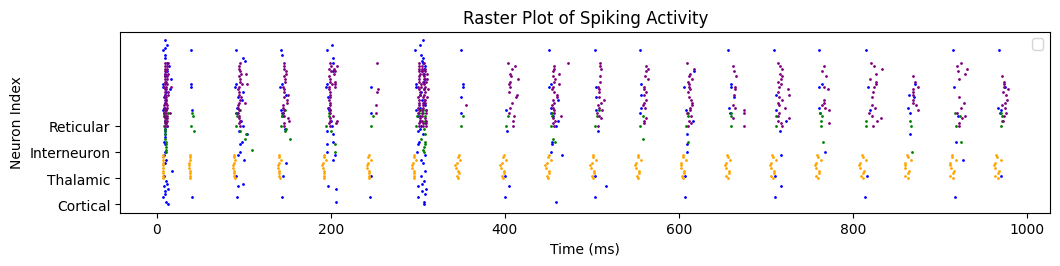

In [37]:
start_scope()

# Parameters

eqs = '''dv/dt = 0.04/mV/ms * v**2 + 5/ms * v + 140*mV/ms - u/ms + I/(0.1*nF) : volt
         du/dt = a*(b*v - u)/ms : volt
         I : amp
         a : 1
         b : 1
         c : volt
         d : volt
         '''
# Create a cortical neuron group
Cortical = NeuronGroup(65, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='euler') 

Cortical.a = 0.02
Cortical.b = 0.2
Cortical.c = -65*mV
Cortical.d = 8*mV
Cortical.I = '0*pA' # Random background input to cortex 

Cortical.v = Cortical.c
Cortical.u = Cortical.b * -65*mV

# Create a low order thalamic neuron group (e.g., ventral posterior nucleus)
Thalamic = NeuronGroup(10, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='euler')


Thalamic.a = 0.02
Thalamic.b = 0.25
Thalamic.c = -65*mV
Thalamic.d = 2*mV
Thalamic.I = '200*pA' # Only low order thalamic neurons are driven by sensory input

Thalamic.v = Thalamic.c
Thalamic.u = Thalamic.b * -65*mV

# Create a fast-spiking interneuron group
Interneuron = NeuronGroup(17, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='euler')

Interneuron.a = 0.1
Interneuron.b = 0.2
Interneuron.c = -65*mV
Interneuron.d = 0.05*mV
Interneuron.I = '0*pA' # Interneurons are driven by cortex

Interneuron.v = Interneuron.c 
Interneuron.u = Interneuron.b * -65*mV

# Create a high order thalamic neuron group (e.g., reticular nucleus)
Reticular = NeuronGroup(25, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='euler')
Reticular.a = 0.02
Reticular.b = 0.25
Reticular.c = -65*mV
Reticular.d = 2*mV
Reticular.I = '0*pA' # Reticular neurons are driven by cortex 

Reticular.v = Reticular.c
Reticular.u = Reticular.b * -65*mV

# Create synapses

Cortical_to_Cortical = Synapses(Cortical, Cortical, 'w : volt', on_pre='v += w')
Cortical_to_Cortical.connect(condition= 'i!=j', p=0.1)
Cortical_to_Cortical.w = '0.5*mV + 0.5*mV*rand()'

Cortical_to_Thalamic = Synapses(Cortical, Thalamic, 'w : volt', on_pre='v += w')
Cortical_to_Thalamic.connect(condition= 'i!=j', p=0.05)
Cortical_to_Thalamic.w = '0.2*mV + 0.3*mV*rand()'

Cortical_to_Interneuron = Synapses(Cortical, Interneuron, 'w : volt', on_pre='v += w')
Cortical_to_Interneuron.connect(condition= 'i!=j', p=0.2)
Cortical_to_Interneuron.w = '5*mV + 1*mV*rand()'

Cortical_to_Reticular = Synapses(Cortical, Reticular, 'w : volt', on_pre='v += w')
Cortical_to_Reticular.connect(condition= 'i!=j', p=0.5)
Cortical_to_Reticular.w = '3*mV + 1*mV*rand()'

Thalamic_to_Cortical = Synapses(Thalamic, Cortical, 'w : volt', on_pre='v += w')
Thalamic_to_Cortical.connect(condition = 'i!=j', p=0.25)
Thalamic_to_Cortical.w = '6*mV + 2*mV*rand()' # Unrealistically strong synapses to ensure thalamic drive

Thalamic_to_Interneuron = Synapses(Thalamic, Interneuron, 'w : volt', on_pre='v += w')
Thalamic_to_Interneuron.connect(condition = 'i!=j', p=0.2)
Thalamic_to_Interneuron.w = '5*mV + 1*mV*rand()'

Interneuron_to_Cortical = Synapses(Interneuron, Cortical, 'w : volt', on_pre='v += w')
Interneuron_to_Cortical.connect(condition = 'i!=j', p=0.4) 
Interneuron_to_Cortical.w = '-2*mV + -2*mV*rand()'

Interneuron_to_Interneuron = Synapses(Interneuron, Interneuron, 'w : volt', on_pre='v += w')
Interneuron_to_Interneuron.connect(condition = 'i!=j', p=0.4)
Interneuron_to_Interneuron.w = '-1*mV + -1*mV*rand()'

Interneuron_to_Thalamic = Synapses(Interneuron, Thalamic, 'w : volt', on_pre='v += w')
Interneuron_to_Thalamic.connect(condition = 'i!=j', p=0.2)
Interneuron_to_Thalamic.w = '-1*mV + -1*mV*rand()'

Reticular_to_Cortical = Synapses(Reticular, Cortical, 'w : volt', on_pre='v += w')
Reticular_to_Cortical.connect(condition = 'i!=j', p=0.2)
Reticular_to_Cortical.w = '3*mV + 1*mV*rand()'



# Record the results
MC = StateMonitor(Cortical, 'v', record=True)
MT = StateMonitor(Thalamic, 'v', record=True)
MI = StateMonitor(Interneuron, 'v', record=True)
MR = StateMonitor(Reticular, 'v', record=True)

Spikemon_Cortical = SpikeMonitor(Cortical)
Spikemon_Thalamic = SpikeMonitor(Thalamic)
Spikemon_Interneuron = SpikeMonitor(Interneuron)
Spikemon_Reticular = SpikeMonitor(Reticular)

print(f"Thalamic→Cortical synapses: {len(Thalamic_to_Cortical)}")
print(f"Avg thalamic inputs per cortical neuron: {len(Thalamic_to_Cortical)/50:.1f}")
print(f"Cortical dv/dt at rest with I=50pA: {(0.04*(-65)**2 + 5*(-65) + 140 + 50e-12/1e-10):.2f} mV/ms")

run(1000*ms)

# Plot the results
plt.figure(figsize=(20, 12))
plt.subplot(3, 1, 1)
plt.plot(MC.t/ms, MC.v[0]/mV, label='Cortical Neuron')
#plt.plot(MT.t/ms, MT.v[0]/mV, label='Thalamic Neuron')
#plt.plot(MI.t/ms, MI.v[0]/mV, label='Interneuron')
#plt.plot(MR.t/ms, MR.v[0]/mV, label='Reticular Neuron')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.title('Neural Activity')
plt.show()

# Plot the raster plot
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 2)
plot(Spikemon_Cortical.t/ms, Spikemon_Cortical.i, '.k', color='blue', markersize=2)
plot(Spikemon_Thalamic.t/ms, Spikemon_Thalamic.i + 10, '.k', color='orange', markersize=2)
plot(Spikemon_Interneuron.t/ms, Spikemon_Interneuron.i + 20, '.r', color='green', markersize=2)
plot(Spikemon_Reticular.t/ms, Spikemon_Reticular.i + 30, '.k', color='purple', markersize=2)
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index')
plt.yticks([0, 10, 20, 30], ['Cortical', 'Thalamic', 'Interneuron', 'Reticular'])
plt.legend()
plt.title('Raster Plot of Spiking Activity')
plt.show()

Thalamic→Cortical synapses: 6755
Avg thalamic inputs per cortical neuron: 135.1
Cortical dv/dt at rest with I=50pA: -15.50 mV/ms
Cortical E:    8.0 Hz
LO Thalamic:   20.7 Hz
Interneuron:   33.3 Hz
HO Thalamic:   13.3 Hz


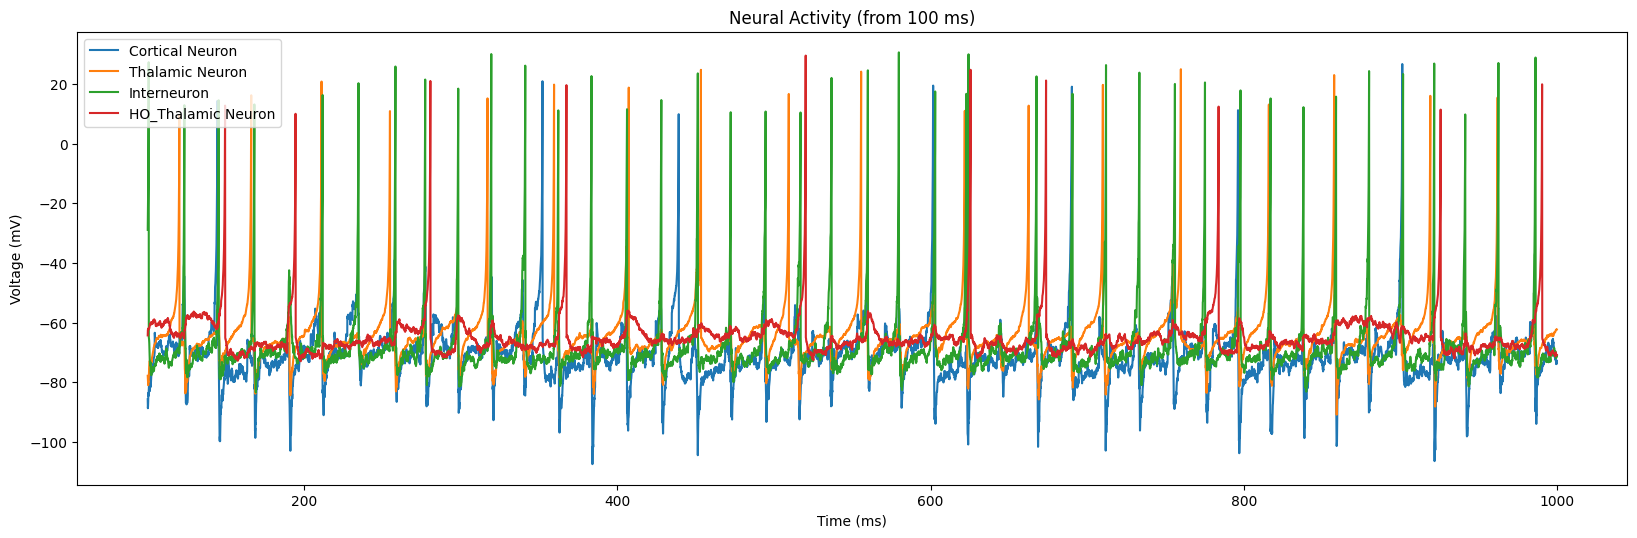

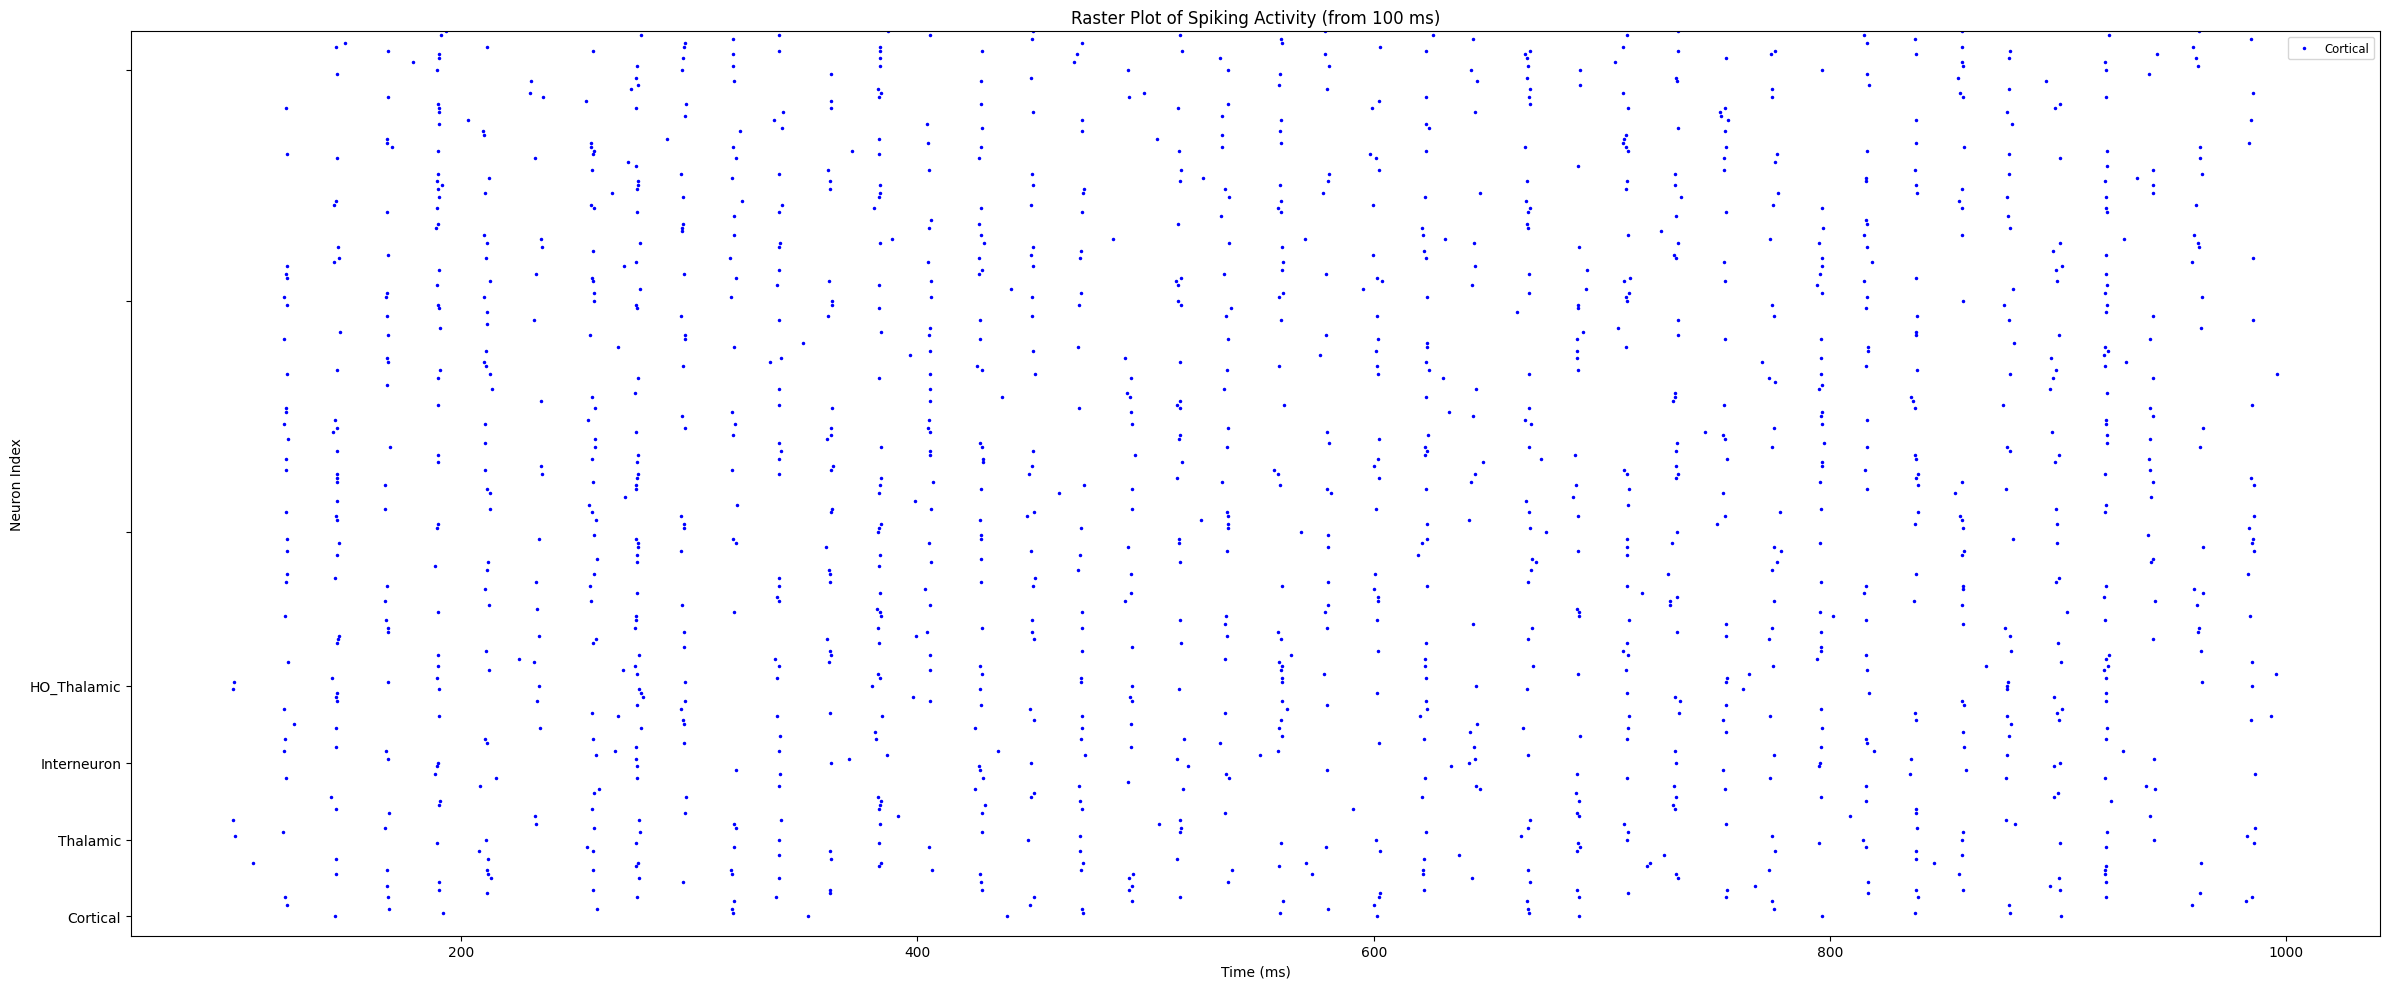

In [14]:
start_scope()

# Parameters

eqs = '''dv/dt = 0.04/mV/ms * v**2 + 5/ms * v + 140*mV/ms - u/ms + I/(100*pF) + sigma*xi*(mV/ms**0.5) : volt
         du/dt = a*(b*v - u)/ms : volt
         I : amp
         sigma : 1
         a : 1
         b : 1
         c : volt
         d : volt
         '''
# Create a cortical neuron group
Cortical = NeuronGroup(650, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='milstein') 

Cortical.a = 0.02
Cortical.b = 0.2
Cortical.c = -65*mV
Cortical.d = 8*mV
Cortical.I = '100*pA' # Random background input to cortex 

Cortical.v = Cortical.c
Cortical.u = Cortical.b * -65*mV

# Create a low order thalamic neuron group (e.g., ventral posterior nucleus)
Thalamic = NeuronGroup(70, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='milstein')


Thalamic.a = 0.02
Thalamic.b = 0.25
Thalamic.c = -65*mV
Thalamic.d = 2*mV
Thalamic.I = '200*pA' # Only low order thalamic neurons are driven by sensory input

Thalamic.v = Thalamic.c
Thalamic.u = Thalamic.b * -65*mV

# Create a fast-spiking interneuron group
Interneuron = NeuronGroup(170, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='milstein')

Interneuron.a = 0.1
Interneuron.b = 0.2
Interneuron.c = -65*mV
Interneuron.d = 2*mV
Interneuron.I = '0*pA' # Interneurons are driven by cortex

Interneuron.v = Interneuron.c 
Interneuron.u = Interneuron.b * -65*mV

# Create a high order thalamic neuron group 
HO_Thalamic = NeuronGroup(130, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='milstein')
HO_Thalamic.a = 0.02
HO_Thalamic.b = 0.25
HO_Thalamic.c = -65*mV
HO_Thalamic.d = 2*mV
HO_Thalamic.I = '0*pA' # High-order thalamic neurons are driven by cortex 

HO_Thalamic.v = HO_Thalamic.c
HO_Thalamic.u = HO_Thalamic.b * -65*mV

# Random noise

Cortical.sigma = 2.0    # tune this — higher = more irregular firing
Interneuron.sigma = 1.5
HO_Thalamic.sigma = 1.0
Thalamic.sigma = 0.5  

# Create synapses

Cortical_to_Cortical = Synapses(Cortical, Cortical, 'w : volt', on_pre='v += w')
Cortical_to_Cortical.connect(condition= 'i!=j', p=0.15)
Cortical_to_Cortical.w = '0.5*mV + 0.5*mV*rand()'

Cortical_to_Thalamic = Synapses(Cortical, Thalamic, 'w : volt', on_pre='v += w')
Cortical_to_Thalamic.connect( p=0.05)
Cortical_to_Thalamic.w = '1*mV + 0.3*mV*rand()'

Cortical_to_HO_Thalamic = Synapses(Cortical, HO_Thalamic, 'w : volt', on_pre='v += w')
Cortical_to_HO_Thalamic.connect(p=0.05)
Cortical_to_HO_Thalamic.w = '1*mV + 1*mV*rand()'

Cortical_to_Interneuron = Synapses(Cortical, Interneuron, 'w : volt', on_pre='v += w')
Cortical_to_Interneuron.connect(p=0.2)
Cortical_to_Interneuron.w = '2*mV + 0.5*mV*rand()' # This weight is very important 

Thalamic_to_Cortical = Synapses(Thalamic, Cortical, 'w : volt', on_pre='v += w')
Thalamic_to_Cortical.connect(p=0.15)
Thalamic_to_Cortical.w = '4*mV + 2*mV*rand()' 

Thalamic_to_Interneuron = Synapses(Thalamic, Interneuron, 'w : volt', on_pre='v += w')
Thalamic_to_Interneuron.connect(p=0.2)
Thalamic_to_Interneuron.w = '1.5*mV + 1*mV*rand()'

Interneuron_to_Cortical = Synapses(Interneuron, Cortical, 'w : volt', on_pre='v += w')
Interneuron_to_Cortical.connect(p=0.4) 
Interneuron_to_Cortical.w = '-1.5*mV + (-0.5*mV*rand())'

Interneuron_to_Interneuron = Synapses(Interneuron, Interneuron, 'w : volt', on_pre='v += w')
Interneuron_to_Interneuron.connect(condition = 'i!=j', p=0.4)
Interneuron_to_Interneuron.w = '-0.5*mV + (-1*mV*rand())'

Interneuron_to_Thalamic = Synapses(Interneuron, Thalamic, 'w : volt', on_pre='v += w')
Interneuron_to_Thalamic.connect(p=0.2)
Interneuron_to_Thalamic.w = '-1*mV + (-1*mV*rand())'

HO_Thalamic_to_Cortical = Synapses(HO_Thalamic, Cortical, 'w : volt', on_pre='v += w')
HO_Thalamic_to_Cortical.connect(p=0.02)
HO_Thalamic_to_Cortical.w = '6*mV + 1*mV*rand()'

HO_to_Interneuron = Synapses(HO_Thalamic, Interneuron, 'w : volt', on_pre='v += w')
HO_to_Interneuron.connect(p=0.04)
HO_to_Interneuron.w = '1.5*mV + 0.5*mV*rand()'

# Record the results
MC = StateMonitor(Cortical, 'v', record=True)
MT = StateMonitor(Thalamic, 'v', record=True)
MI = StateMonitor(Interneuron, 'v', record=True)
MR = StateMonitor(HO_Thalamic, 'v', record=True)

Spikemon_Cortical = SpikeMonitor(Cortical)
Spikemon_Thalamic = SpikeMonitor(Thalamic)
Spikemon_Interneuron = SpikeMonitor(Interneuron)
Spikemon_HO_Thalamic = SpikeMonitor(HO_Thalamic)

print(f"Thalamic→Cortical synapses: {len(Thalamic_to_Cortical)}")
print(f"Avg thalamic inputs per cortical neuron: {len(Thalamic_to_Cortical)/50:.1f}")
print(f"Cortical dv/dt at rest with I=50pA: {(0.04*(-65)**2 + 5*(-65) + 140 + 50e-12/1e-10):.2f} mV/ms")

run(1000*ms)

duration = 1000*ms  # your post-trim window

rate_cortical = Spikemon_Cortical.num_spikes / (650 * duration)
rate_thalamic = Spikemon_Thalamic.num_spikes / (70 * duration)
rate_interneuron = Spikemon_Interneuron.num_spikes / (170 * duration)
rate_HO = Spikemon_HO_Thalamic.num_spikes / (130 * duration)

print(f"Cortical E:    {rate_cortical:.1f} Hz")
print(f"LO Thalamic:   {rate_thalamic:.1f} Hz")
print(f"Interneuron:   {rate_interneuron:.1f} Hz")
print(f"HO Thalamic:   {rate_HO:.1f} Hz")

# Trim the first 100 ms from plots
trim_ms = 100
trim_mask = (MC.t/ms >= trim_ms)
trim_idx = np.nonzero(trim_mask)[0]

# Plot the results
plt.figure(figsize=(20, 20))
plt.subplot(3, 1, 1)
plt.plot((MC.t/ms)[trim_idx], (MC.v[0]/mV)[trim_idx], label='Cortical Neuron')
plt.plot((MT.t/ms)[trim_idx], (MT.v[0]/mV)[trim_idx], label='Thalamic Neuron')
plt.plot((MI.t/ms)[trim_idx], (MI.v[0]/mV)[trim_idx], label='Interneuron')
plt.plot((MR.t/ms)[trim_idx], (MR.v[0]/mV)[trim_idx], label='HO_Thalamic Neuron')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.title('Neural Activity (from 100 ms)')
plt.show()

# Plot the raster plot
plt.figure(figsize=(24, 10))
plt.plot((Spikemon_Cortical.t/ms)[Spikemon_Cortical.t/ms >= trim_ms], Spikemon_Cortical.i[Spikemon_Cortical.t/ms >= trim_ms], marker='.', linestyle='None', color='blue', markersize=3, label='Cortical')
#plt.plot((Spikemon_Thalamic.t/ms)[Spikemon_Thalamic.t/ms >= trim_ms], Spikemon_Thalamic.i[Spikemon_Thalamic.t/ms >= trim_ms] + 20, marker='.', linestyle='None', color='orange', markersize=3, label='Thalamic')
#plt.plot((Spikemon_Interneuron.t/ms)[Spikemon_Interneuron.t/ms >= trim_ms], Spikemon_Interneuron.i[Spikemon_Interneuron.t/ms >= trim_ms] + 40, marker='.', linestyle='None', color='green', markersize=3, label='Interneuron')
#plt.plot((Spikemon_HO_Thalamic.t/ms)[Spikemon_HO_Thalamic.t/ms >= trim_ms], Spikemon_HO_Thalamic.i[Spikemon_HO_Thalamic.t/ms >= trim_ms] + 60, marker='.', linestyle='None', color='purple', markersize=3, label='HO_Thalamic')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index')
plt.ylim(-5, 230)
plt.yticks([0, 20, 40, 60, 100, 160, 220], ['Cortical', 'Thalamic', 'Interneuron', 'HO_Thalamic', '', '', ''])
plt.legend(loc='upper right', fontsize='small')
plt.title('Raster Plot of Spiking Activity (from 100 ms)')
plt.tight_layout()
plt.show()



Thalamic→Cortical synapses: 6787
Avg thalamic inputs per cortical neuron: 135.7
Cortical dv/dt at rest with I=50pA: -15.50 mV/ms
Cortical E:    11.1 Hz
LO Thalamic:   20.3 Hz
Interneuron:   40.6 Hz
HO Thalamic:   17.3 Hz


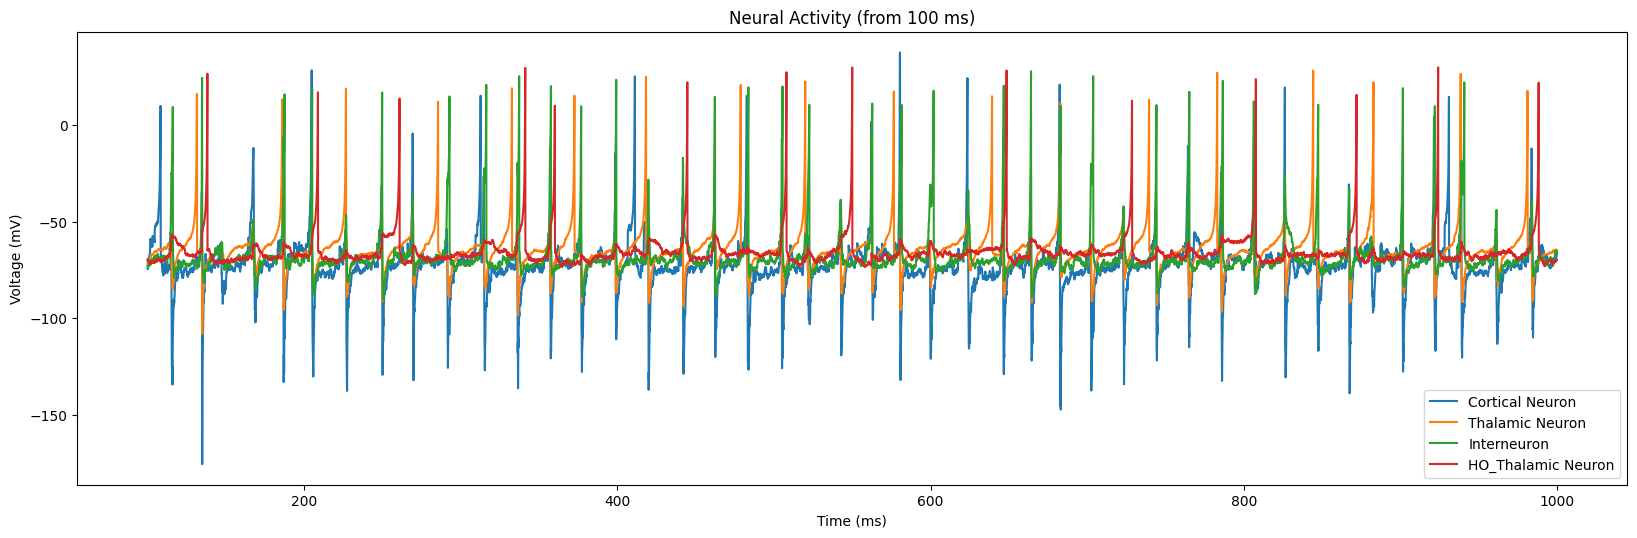

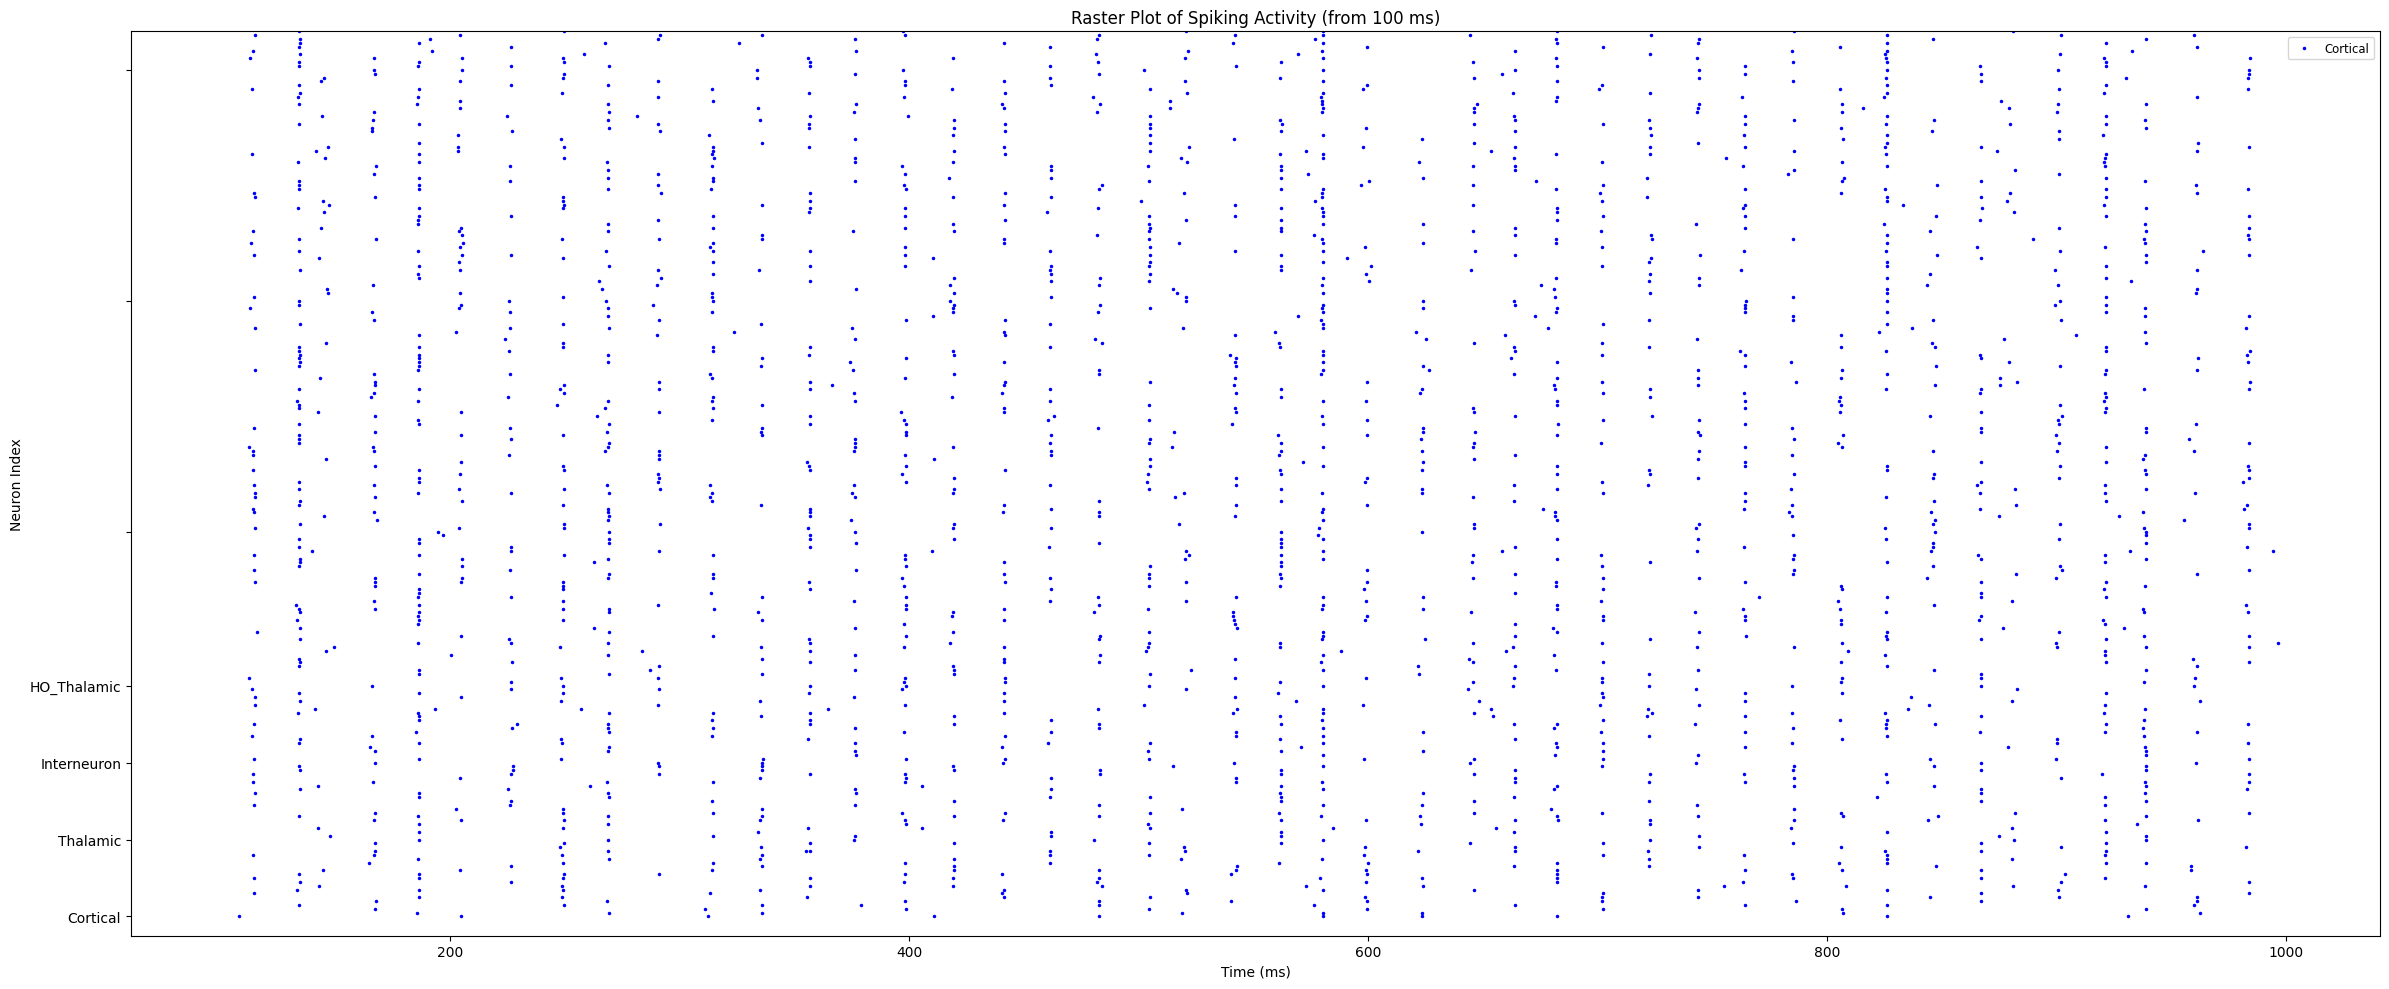

In [15]:
start_scope()

# Parameters

eqs = '''dv/dt = 0.04/mV/ms * v**2 + 5/ms * v + 140*mV/ms - u/ms + I/(100*pF) + sigma*xi*(mV/ms**0.5) : volt
         du/dt = a*(b*v - u)/ms : volt
         I : amp
         sigma : 1
         a : 1
         b : 1
         c : volt
         d : volt
         '''
# Create a cortical neuron group
Cortical = NeuronGroup(650, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='milstein') 

Cortical.a = 0.02
Cortical.b = 0.2
Cortical.c = -65*mV
Cortical.d = 8*mV
Cortical.I = '100*pA' # Random background input to cortex 

Cortical.v = Cortical.c
Cortical.u = Cortical.b * -65*mV

# Create a low order thalamic neuron group (e.g., ventral posterior nucleus)
Thalamic = NeuronGroup(70, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='milstein')


Thalamic.a = 0.02
Thalamic.b = 0.25
Thalamic.c = -65*mV
Thalamic.d = 2*mV
Thalamic.I = '200*pA' # Only low order thalamic neurons are driven by sensory input

Thalamic.v = Thalamic.c
Thalamic.u = Thalamic.b * -65*mV

# Create a fast-spiking interneuron group
Interneuron = NeuronGroup(170, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='milstein')

Interneuron.a = 0.1
Interneuron.b = 0.2
Interneuron.c = -65*mV
Interneuron.d = 2*mV
Interneuron.I = '0*pA' # Interneurons are driven by cortex

Interneuron.v = Interneuron.c 
Interneuron.u = Interneuron.b * -65*mV

# Create a high order thalamic neuron group 
HO_Thalamic = NeuronGroup(130, eqs, threshold='v >= 30*mV', reset='v = c; u += d', method='milstein')
HO_Thalamic.a = 0.02
HO_Thalamic.b = 0.25
HO_Thalamic.c = -65*mV
HO_Thalamic.d = 2*mV
HO_Thalamic.I = '0*pA' # High-order thalamic neurons are driven by cortex 

HO_Thalamic.v = HO_Thalamic.c
HO_Thalamic.u = HO_Thalamic.b * -65*mV

# Random noise

Cortical.sigma = 2.0    # tune this — higher = more irregular firing
Interneuron.sigma = 1.5
HO_Thalamic.sigma = 1.0
Thalamic.sigma = 0.5  

# Create synapses

Cortical_to_Cortical = Synapses(Cortical, Cortical, 'w : volt', on_pre='v += w')
Cortical_to_Cortical.connect(condition= 'i!=j', p=0.15)
Cortical_to_Cortical.w = '2*mV + 0.5*mV*rand()' # Changing this weight and cortical to interneuron weight are ways to make cortical firing more or less uniform 
Cortical_to_Thalamic = Synapses(Cortical, Thalamic, 'w : volt', on_pre='v += w')
Cortical_to_Thalamic.connect( p=0.05)
Cortical_to_Thalamic.w = '1*mV + 0.3*mV*rand()'

Cortical_to_HO_Thalamic = Synapses(Cortical, HO_Thalamic, 'w : volt', on_pre='v += w')
Cortical_to_HO_Thalamic.connect(p=0.05)
Cortical_to_HO_Thalamic.w = '1*mV + 1*mV*rand()'

Cortical_to_Interneuron = Synapses(Cortical, Interneuron, 'w : volt', on_pre='v += w')
Cortical_to_Interneuron.connect(p=0.2)
Cortical_to_Interneuron.w = '2*mV + 0.5*mV*rand()' # This weight is very important 

Thalamic_to_Cortical = Synapses(Thalamic, Cortical, 'w : volt', on_pre='v += w')
Thalamic_to_Cortical.connect(p=0.15)
Thalamic_to_Cortical.w = '4*mV + 2*mV*rand()' 

Thalamic_to_Interneuron = Synapses(Thalamic, Interneuron, 'w : volt', on_pre='v += w')
Thalamic_to_Interneuron.connect(p=0.2)
Thalamic_to_Interneuron.w = '1.5*mV + 1*mV*rand()'

Interneuron_to_Cortical = Synapses(Interneuron, Cortical, 'w : volt', on_pre='v += w')
Interneuron_to_Cortical.connect(p=0.4) 
Interneuron_to_Cortical.w = '-3*mV + (-0.5*mV*rand())'

Interneuron_to_Interneuron = Synapses(Interneuron, Interneuron, 'w : volt', on_pre='v += w')
Interneuron_to_Interneuron.connect(condition = 'i!=j', p=0.4)
Interneuron_to_Interneuron.w = '-0.5*mV + (-1*mV*rand())'

Interneuron_to_Thalamic = Synapses(Interneuron, Thalamic, 'w : volt', on_pre='v += w')
Interneuron_to_Thalamic.connect(p=0.2)
Interneuron_to_Thalamic.w = '-1*mV + (-1*mV*rand())'

HO_Thalamic_to_Cortical = Synapses(HO_Thalamic, Cortical, 'w : volt', on_pre='v += w')
HO_Thalamic_to_Cortical.connect(p=0.02)
HO_Thalamic_to_Cortical.w = '6*mV + 1*mV*rand()'

HO_to_Interneuron = Synapses(HO_Thalamic, Interneuron, 'w : volt', on_pre='v += w')
HO_to_Interneuron.connect(p=0.04)
HO_to_Interneuron.w = '1.5*mV + 0.5*mV*rand()'

# Record the results
MC = StateMonitor(Cortical, 'v', record=True)
MT = StateMonitor(Thalamic, 'v', record=True)
MI = StateMonitor(Interneuron, 'v', record=True)
MR = StateMonitor(HO_Thalamic, 'v', record=True)

Spikemon_Cortical = SpikeMonitor(Cortical)
Spikemon_Thalamic = SpikeMonitor(Thalamic)
Spikemon_Interneuron = SpikeMonitor(Interneuron)
Spikemon_HO_Thalamic = SpikeMonitor(HO_Thalamic)

print(f"Thalamic→Cortical synapses: {len(Thalamic_to_Cortical)}")
print(f"Avg thalamic inputs per cortical neuron: {len(Thalamic_to_Cortical)/50:.1f}")
print(f"Cortical dv/dt at rest with I=50pA: {(0.04*(-65)**2 + 5*(-65) + 140 + 50e-12/1e-10):.2f} mV/ms")

run(1000*ms)

duration = 1000*ms  # your post-trim window

rate_cortical = Spikemon_Cortical.num_spikes / (650 * duration)
rate_thalamic = Spikemon_Thalamic.num_spikes / (70 * duration)
rate_interneuron = Spikemon_Interneuron.num_spikes / (170 * duration)
rate_HO = Spikemon_HO_Thalamic.num_spikes / (130 * duration)

print(f"Cortical E:    {rate_cortical:.1f} Hz")
print(f"LO Thalamic:   {rate_thalamic:.1f} Hz")
print(f"Interneuron:   {rate_interneuron:.1f} Hz")
print(f"HO Thalamic:   {rate_HO:.1f} Hz")

# Trim the first 100 ms from plots
trim_ms = 100
trim_mask = (MC.t/ms >= trim_ms)
trim_idx = np.nonzero(trim_mask)[0]

# Plot the results
plt.figure(figsize=(20, 20))
plt.subplot(3, 1, 1)
plt.plot((MC.t/ms)[trim_idx], (MC.v[0]/mV)[trim_idx], label='Cortical Neuron')
plt.plot((MT.t/ms)[trim_idx], (MT.v[0]/mV)[trim_idx], label='Thalamic Neuron')
plt.plot((MI.t/ms)[trim_idx], (MI.v[0]/mV)[trim_idx], label='Interneuron')
plt.plot((MR.t/ms)[trim_idx], (MR.v[0]/mV)[trim_idx], label='HO_Thalamic Neuron')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.title('Neural Activity (from 100 ms)')
plt.show()

# Plot the raster plot
plt.figure(figsize=(24, 10))
plt.plot((Spikemon_Cortical.t/ms)[Spikemon_Cortical.t/ms >= trim_ms], Spikemon_Cortical.i[Spikemon_Cortical.t/ms >= trim_ms], marker='.', linestyle='None', color='blue', markersize=3, label='Cortical')
#plt.plot((Spikemon_Thalamic.t/ms)[Spikemon_Thalamic.t/ms >= trim_ms], Spikemon_Thalamic.i[Spikemon_Thalamic.t/ms >= trim_ms] + 20, marker='.', linestyle='None', color='orange', markersize=3, label='Thalamic')
#plt.plot((Spikemon_Interneuron.t/ms)[Spikemon_Interneuron.t/ms >= trim_ms], Spikemon_Interneuron.i[Spikemon_Interneuron.t/ms >= trim_ms] + 40, marker='.', linestyle='None', color='green', markersize=3, label='Interneuron')
#plt.plot((Spikemon_HO_Thalamic.t/ms)[Spikemon_HO_Thalamic.t/ms >= trim_ms], Spikemon_HO_Thalamic.i[Spikemon_HO_Thalamic.t/ms >= trim_ms] + 60, marker='.', linestyle='None', color='purple', markersize=3, label='HO_Thalamic')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index')
plt.ylim(-5, 230)
plt.yticks([0, 20, 40, 60, 100, 160, 220], ['Cortical', 'Thalamic', 'Interneuron', 'HO_Thalamic', '', '', ''])
plt.legend(loc='upper right', fontsize='small')
plt.title('Raster Plot of Spiking Activity (from 100 ms)')
plt.tight_layout()
plt.show()

